In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
sys.path.append("/Users/Shivang/LLM from scratch/LLM-from-Scratch-Self/")
from Chapter_4.gpt import TansformersConfig
from dataclasses import dataclass

In [2]:
# LayerNorm
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        self.scale = torch.Parameter(torch.ones(emb_dim))
        self.bias = torch.Parameter(torch.zeros(emb_dim))
        self.epsilon = 1e-5

    def forward(self, x):
        mean = x.mean(dim=-1, keepdims=True)
        var = x.var(dim=-1, keepdims=True, unbiased=False)
        norm_x = x - mean / (torch.sqrt(self.epsilon + var))

        return norm_x * self.scale + self.bias


# RMSNorm
class RMSNorm(nn.Module):
    def __init__(self, emb_dim, epsilon=1e-5):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(emb_dim))
        self.epsilon = epsilon

    def forward(self, x):
        means = torch.pow(x, 2).mean(dim=-1, keepdims=True)
        x_normed = x * torch.rsqrt(self.epsilon + means)
        return (x_normed * self.weight).to(dtype=x.dtype)


# checking if the implementation is working good
torch.manual_seed(123)

example_batch = torch.randn(2, 3, 4)

rms_norm = RMSNorm(emb_dim=example_batch.shape[-1])
rmsnorm_pytorch = torch.nn.RMSNorm(example_batch.shape[-1], eps=1e-5)

assert torch.allclose(rms_norm(example_batch), rmsnorm_pytorch(example_batch))

In [3]:
# GELU Implementation
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(seff, x):
        return (
            0.5
            * x
            * (
                1
                + torch.tanh(
                    torch.sqrt(torch.tensor(2.0 / torch.pi))
                    * (x + 0.044715 * torch.pow(x, 3))
                )
            )
        )


# SiLU Implementation
class SiLU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x * torch.sigmoid(x)


# checking implementation
silu = SiLU()

assert torch.allclose(silu(example_batch), torch.nn.functional.silu(example_batch))

In [4]:
# # GPT FeedForward
# class FeedForward(nn.Module):
#     def __init__(self, contants):
#         self.layers = nn.Sequential([nn.Linear(self.contants.contants.emb_dim, 4 * self.contants.emb_dim), 
#                     GELU(), 
#                     nn.Linear(4 * self.contants.emb_dim, self.contants.emb_dim)]
#                     )
#     def forward(self, x):
#         return self.layers(x)

## Llama 2 Feedforward
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg.emb_dim, cfg.hidden_dim, dtype = cfg.dtype, bias= False)
        self.fc2 = nn.Linear(cfg.emb_dim, cfg.hidden_dim, dtype = cfg.dtype, bias= False)
        self.fc3 = nn.Linear(cfg.hidden_dim, cfg.emb_dim, dtype = cfg.dtype, bias = False)
        self.silu = SiLU()

    def forward(self, x):
        x_fc1 = self.fc1(x)
        x_fc2 = self.fc2(x)
        x = self.silu(x_fc1) * x_fc2
        return self.fc3(x)


# ROPE : Revise it again

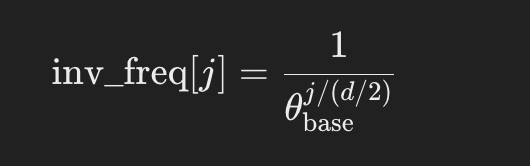

In [5]:
from IPython.display import Image
Image(filename='/Users/Shivang/LLM from scratch/LLM-from-Scratch-Self/Screenshot 2024-10-28.png')



In [6]:
def precompute_rope_params(head_dim, theta_base=10_000, context_length=4096):
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim // 2) / (head_dim // 2)))

    # Generate position indices
    positions = torch.arange(context_length)

    # Compute the angles
    angles = positions[:, None] * inv_freq[None, :]  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin

def compute_rope(x, cos, sin):
    #x = (batch, num_head, seq_len, head_dim)
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 ==0, "head_dim must be even"

    # Split x into first half and second half
    x1 = x[..., : head_dim // 2]  # First half
    x2 = x[..., head_dim // 2 :]  # Second half

    # Adjust sin and cos shapes
    cos = cos[:seq_len, :].unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, head_dim)
    sin = sin[:seq_len, :].unsqueeze(0).unsqueeze(0)

    # Apply the rotary transformation
    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x * cos) + (rotated * sin)

    return x_rotated.to(dtype=x.dtype)

In [7]:
# Settings
batch_size = 2
context_len = 5
num_heads = 4
head_dim = 16

# Instantiate RoPE parameters
cos, sin = precompute_rope_params(head_dim=head_dim, context_length=context_len)

# Dummy query and key tensors
torch.manual_seed(123)
queries = torch.randn(batch_size, context_len, num_heads, head_dim)
keys = torch.randn(batch_size, context_len, num_heads, head_dim)

# Apply rotary position embeddings
queries_rot = compute_rope(queries, cos, sin)
keys_rot = compute_rope(keys, cos, sin)

## Add RoPE to MHA module

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, num_heads, dtype = None):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = self.d_out // self.num_heads

        self.q = nn.Linear(d_in, d_out, bias = False, dtype = dtype)
        self.k = nn.Linear(d_in, d_out, bias = False, dtype = dtype)
        self.v = nn.Linear(d_in, d_out, bias = False, dtype = dtype)

        self.out_proj = nn.Linear(d_out, d_out, bias = False, dtype = dtype)
        #no dropout
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

        cos, sin = precompute_rope_params(head_dim=self.head_dim, context_length=context_length)
        self.register_buffer("cos", cos)
        self.register_buffer("sin", sin)

    def forward(self, x):
        b, num_token, d_in = x.shape

        keys = self.k(x)
        queries = self.q(x)
        values = self.v(x)

        #implicitky split the matrix by adding a `num_heads` dim 
        #unroll last dim: (b, num_token, d_out) ==> (b, num_tokens, num_heads, head_dim)

        keys = keys.view(b, num_token, self.num_heads, self.head_dim)
        queries = queries.view(b, num_token, self.num_heads, self.head_dim)
        values = values.view(b, num_token, self.num_heads, self.head_dim)

        #transpose the 1 and 2 dim
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        #applying rope
        keys = compute_rope(keys, self.cos, self.sin)
        queries = compute_rope(queries, self.cos, self.sin)
        
        attn_scores = queries @ keys.transpose(2, 3)

        mask_bool = self.mask.bool()[:num_token, :num_token]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim = -1)

        context_vec = (attn_weights @ values).transpose(1, 2)
        #
        #  Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_token, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

In [9]:
# Settings
batch_size = 1
context_len = 100
max_context_len = 4096
embed_dim = 128
num_heads = 4


example_batch = torch.randn((batch_size, context_len, embed_dim))

mha = MultiHeadAttention(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=max_context_len,
    num_heads=num_heads
)

mha(example_batch)

del mha  # delete to safe memory

# Transformer Block

In [10]:
class TransformersBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            d_in = cfg.emb_dim,
            d_out = cfg.emb_dim,
            context_length=cfg.emb_dim,
            num_heads = cfg.n_heads,
            dtype = cfg.dtype
        )

        self.ff = FeedForward(cfg)

        #instead of LayerNorm, going to used RMSNorm
        self.norm1 = RMSNorm(cfg.emb_dim)
        self.norm2 = RMSNorm(cfg.emb_dim)

    def forward(self, x):
        #attn block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = x + shortcut

        #ff block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = shortcut + x

        return x

## Llama2 Model Class

In [11]:
class Llama2Model(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.emb_dim, dtype= cfg.dtype)
        self.trf_blocks = nn.Sequential(
            *[TransformersBlock(cfg) for _ in range(cfg.n_layers)]
        )

        self.final_norm = RMSNorm(cfg.emb_dim)
        self.out_head = nn.Linear(cfg.emb_dim, cfg.vocab_size, bias = False, dtype = cfg.dtype)

    def forward(self, in_idx):
        b, token_len = in_idx.shape
        token_embeds = self.tok_emb(in_idx)

        x = token_embeds
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
    

In [12]:
#constants
@dataclass
class Config_GPT:
    vocab_size: int
    context_length: int
    emb_dim: int
    n_heads: int
    n_layers: int
    drop_rate: float
    qkv_bias: bool

@dataclass
class Config_Llama:
    vocab_size: int
    context_length: int
    emb_dim: int
    n_heads: int
    n_layers: int
    hidden_dim:int
    dtype: torch.bfloat16


GPT_CONFIG_124M = Config_GPT(
        vocab_size=50257,
        context_length=1024,
        emb_dim=768,
        n_heads=12,
        n_layers=12,
        drop_rate=0.1,
        qkv_bias=False,
    )

GPT_CONFIG_1558M = Config_GPT(
        vocab_size=50257,
        context_length=1024,
        emb_dim=1600,
        n_heads=25,
        n_layers=48,
        drop_rate=0.1,
        qkv_bias=False,
    )

LLAMA2_CONFIG_7B = Config_Llama(
    vocab_size= 32000,     
    context_length= 4096,  
    emb_dim= 4096,         
    n_heads= 32,           
    n_layers= 32,          
    hidden_dim= 11008,     
    dtype= torch.bfloat16
)

In [13]:
model = Llama2Model(LLAMA2_CONFIG_7B)

In [14]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 6,738,415,616


In [15]:
def model_memory_size(model, input_dtype=torch.float32):
    total_params = 0
    total_grads = 0
    for param in model.parameters():
        # Calculate total number of elements per parameter
        param_size = param.numel()
        total_params += param_size
        # Check if gradients are stored for this parameter
        if param.requires_grad:
            total_grads += param_size

    # Calculate buffer size (non-parameters that require memory)
    total_buffers = sum(buf.numel() for buf in model.buffers())

    # Size in bytes = (Number of elements) * (Size of each element in bytes)
    # We assume parameters and gradients are stored in the same type as input dtype
    element_size = torch.tensor(0, dtype=input_dtype).element_size()
    total_memory_bytes = (total_params + total_grads + total_buffers) * element_size

    # Convert bytes to gigabytes
    total_memory_gb = total_memory_bytes / (1024**3)

    return total_memory_gb

print(f"float32 (PyTorch default): {model_memory_size(model, input_dtype=torch.float32):.2f} GB")
print(f"bfloat16: {model_memory_size(model, input_dtype=torch.bfloat16):.2f} GB")

float32 (PyTorch default): 52.33 GB
bfloat16: 26.17 GB


# Loading the Model

In [16]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    model.to(device)

In [17]:
from huggingface_hub import login
import json

with open("token.json", "r") as config_file:
    config = json.load(config_file)
    access_token = config["HF_ACCESS_TOKEN"]

login(token=access_token)

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid.
Your token has been saved to /Users/shivaays/.cache/huggingface/token
Login successful


In [18]:
from huggingface_hub import hf_hub_download

tokenizer_file = hf_hub_download(
    repo_id="meta-llama/Llama-2-7b",
    filename="tokenizer.model",
    local_dir="Llama-2-7B"
)

In [19]:
import sentencepiece as spm

class LlamaTokenizer:
    def __init__(self, filepath):
        sp = spm.SentencePieceProcessor()
        sp.load(filepath)
        self.tokenizer = sp

    def encode(self, text):
        return self.tokenizer.encode_as_ids(text)
    
    def decode(self, ids):
        return self.tokenizer.decode_pieces(ids)
    

tokenizer = LlamaTokenizer(tokenizer_file)


In [20]:
from utils import generate, text_to_token_ids, token_ids_to_text

torch.manual_seed(123)

token_ids = generate(model = model,
                    idx=text_to_token_ids("Every effort moves", tokenizer).to(device),
                    max_new_tokens=30,
                    context_size=LLAMA2_CONFIG_7B.context_length,
                    top_k=1,
                    temperature=0.
                    )

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort movesαllRadius deletingpretcc否']; future eer napulate lackус während inter DES издаSchéon로жа Bass differencespadxsnu ;; ctx始


# Loading the pretrained weights


In [22]:
weights_file = hf_hub_download(
   repo_id="meta-llama/Llama-2-7b",
   filename="consolidated.00.pth",
   local_dir="Llama-2-7b"
)

In [23]:
weights = torch.load(weights_file, weights_only = True)
list(weights.keys())[:15]

['tok_embeddings.weight',
 'norm.weight',
 'output.weight',
 'layers.0.attention.wq.weight',
 'layers.0.attention.wk.weight',
 'layers.0.attention.wv.weight',
 'layers.0.attention.wo.weight',
 'layers.0.feed_forward.w1.weight',
 'layers.0.feed_forward.w2.weight',
 'layers.0.feed_forward.w3.weight',
 'layers.0.attention_norm.weight',
 'layers.0.ffn_norm.weight',
 'layers.1.attention.wq.weight',
 'layers.1.attention.wk.weight',
 'layers.1.attention.wv.weight']

In [24]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")

    if isinstance(right, torch.Tensor):
        return torch.nn.Parameter(right.clone().detach())
    else:
        return torch.nn.Parameter(torch.tensor(right))
    
def load_weights_into_llama(model, param_config, params):
    model.tok_emb.weight = assign(model.tok_emb.weight, params["tok_embeddings.weight"])

    for l in range(param_config.n_layers):

        # Load attention weights
        model.trf_blocks[l].att.q.weight = assign(
            model.trf_blocks[l].att.q.weight,
            params[f"layers.{l}.attention.wq.weight"]
        )
        model.trf_blocks[l].att.k.weight = assign(
            model.trf_blocks[l].att.k.weight,
            params[f"layers.{l}.attention.wk.weight"]
        )
        model.trf_blocks[l].att.v.weight = assign(
            model.trf_blocks[l].att.v.weight,
            params[f"layers.{l}.attention.wv.weight"]
        )
        model.trf_blocks[l].att.out_proj.weight = assign(
            model.trf_blocks[l].att.out_proj.weight,
            params[f"layers.{l}.attention.wo.weight"]
        )
        model.trf_blocks[l].norm1.weight = assign(
            model.trf_blocks[l].norm1.weight,
            params[f"layers.{l}.attention_norm.weight"]
        )

        # Load FeedForward weights
        model.trf_blocks[l].ff.fc1.weight = assign(
            model.trf_blocks[l].ff.fc1.weight,
            params[f"layers.{l}.feed_forward.w1.weight"]
        )
        # For some reason w2 and w3 are provided in the wrong order in the weights file
        model.trf_blocks[l].ff.fc2.weight = assign(
            model.trf_blocks[l].ff.fc2.weight,
            params[f"layers.{l}.feed_forward.w3.weight"]
        )
        model.trf_blocks[l].ff.fc3.weight = assign(
            model.trf_blocks[l].ff.fc3.weight,
            params[f"layers.{l}.feed_forward.w2.weight"]
        )
        model.trf_blocks[l].norm2.weight = assign(
            model.trf_blocks[l].norm2.weight,
            params[f"layers.{l}.ffn_norm.weight"]
        )

    # Load output layer weights
    model.final_norm.weight = assign(model.final_norm.weight, params["norm.weight"])
    model.out_head.weight = assign(model.out_head.weight, params["output.weight"])


load_weights_into_llama(model, LLAMA2_CONFIG_7B, weights)
model.to(device)

Llama2Model(
  (tok_emb): Embedding(32000, 4096)
  (trf_blocks): Sequential(
    (0): TransformersBlock(
      (att): MultiHeadAttention(
        (q): Linear(in_features=4096, out_features=4096, bias=False)
        (k): Linear(in_features=4096, out_features=4096, bias=False)
        (v): Linear(in_features=4096, out_features=4096, bias=False)
        (out_proj): Linear(in_features=4096, out_features=4096, bias=False)
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=4096, out_features=11008, bias=False)
        (fc2): Linear(in_features=4096, out_features=11008, bias=False)
        (fc3): Linear(in_features=11008, out_features=4096, bias=False)
        (silu): SiLU()
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
    (1): TransformersBlock(
      (att): MultiHeadAttention(
        (q): Linear(in_features=4096, out_features=4096, bias=False)
        (k): Linear(in_features=4096, out_features=4096, bias=False)
        (v): Linear(in_features=4096, out_fe

In [25]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=25,
    context_size=LLAMA2_CONFIG_7B.context_length,
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort has been made to ensure that the information contained in this website is accurate and up to date and correct at the time of publication
